In [1]:
import sisl
import numpy as np
import matplotlib.pyplot as plt
from ase.visualize import view
from tqdm.notebook import tqdm

import ipywidgets
from ipywidgets import interact
from fractions import Fraction




import utils
print(f"utils : {utils.__version__}")
from utils.structure import build_electrode, build_nanoribbon, build_reduced_device, find_nearest_atoms, infer_centersize
from utils.energies import hamiltonian, multi_LDOS_parallel, multi_LDOS
from utils.loader import path_finder, load_datastructure
from utils import pretty_print_columns
from utils._wrappers import timeit

# Initialize sisl plotting system
# -------------------------------
# sisl uses lazy-loading for Geometry.plot, so the first call after
# a kernel restart can fail. We call plot() on a small dummy ribbon
# here to ensure the plotting system is ready before importing
# utils.plots, which calls .plot() internally.
# _ = sisl.geom.graphene_nanoribbon(1).plot()

from utils.plots import plot_with_center, mark_electrode # plotting


# %reload_ext line_profiler



utils : 0.2.2


# Global parameters

In [2]:
ENERGIES = np.linspace(-2, 2, num=50)

# Benchmark full device: flake convergence
This is how I expect the final structure to converge when computing the LDOS from self-energies. Calculated using [flake_size_conv.py](../../QTM/flake_size_conv.py)

<img src="../../QTM/figures/flake_size_conv.svg">

In [3]:
@timeit
def electrode_dos(ham, nk, energies):
    """compute DOS from built-ins
    
    Parameters
    ----------
    ham : Hamiltonian of shape (K, K)
        Hamiltonian in question 
    nk : int
        number of k points
    energies : ndarray of shape (N,)
        list of energies to compute the dos

    Returns
    -------
    dos : ndarray of shape (N,)
        density of state
    bs : ndarray of shape (M, N)
        bandstructure eigenvalues 
    lk : ndarray of shape (M,)
        scaled kpoints to linear values for use in plotting
    """
    dist = sisl.get_distribution(method="lorentzian", smearing=0.05)
    
    bz = sisl.MonkhorstPack(ham, [nk, 1, 1])
    kvecs = [[0,0,0], [0.5, 0, 0]]
    bands = sisl.BandStructure(ham, kvecs, 15, [r"$\Gamma$", "$K$"])
    lk, kticks, knames = bands.lineark(ticks=True)
    bs = bands.apply.array.eigh()
    dos = (bz.apply.average).eigenstate(wrap = lambda x: x.DOS(energies, distribution=dist)) 
    return dos, bs, (lk, kticks, knames)

In [4]:
def plot_dos_band(device, nk, energies, LWC):
    L, W, C = LWC
    """Plot the device band structure and DOS"""
    H = hamiltonian(device)
    dos, bands, k = electrode_dos(H, nk, energies)
    fig, axes = plt.subplots(1,2, sharey=True)
    fig.suptitle(f"Electrode L={L}, W={W}, C={C}")
    axes[0].set_title("Band structure")    
    axes[0].plot(k[0], bands)    
    axes[0].set_xlabel("$k$", size=15)
    axes[0].set_xticks(k[1])
    axes[0].set_xticklabels(k[2])
    
    axes[1].set_title("DOS")
    axes[1].plot(dos, energies, label="built-in DOS")
    axes[1].set_xlabel("DOS", size=15)
    
    axes[0].set_ylabel("E", size=15)
    fig.tight_layout()
    for ax in axes:
        ax.grid()
    
    return fig, axes

# Benchmark Electrode: self-energy method against built-in

In [5]:
i = 6
length = 2
LWC = infer_centersize(length, i)
electrode, ribbon, _, DATA = load_datastructure(LWC)
lr_idx = DATA["lr_idx"]
atoms_style = mark_electrode(lr_idx[:, 0, :], scale_func=lambda x: 0.5)

# sisl.geom.graphene_nanoribbon(3).tile(3, 0).plot(axes="xy")
plot_with_center(ribbon, atoms_style=atoms_style)

(l, i) = (2, 6) are incompatbile. Increasing i.
params : (L, W, C) = (2, 29, 7)


## Built-in calculations for bands and DOS

In [6]:
i = 6
length = 2
LWC = infer_centersize(length, i)
electrode, ribbon, _, DATA = load_datastructure(LWC)
lr_idx = DATA["lr_idx"]
atoms_style = mark_electrode(lr_idx[:, 0, :], scale_func=lambda x: 0.5)

plot_with_center(ribbon, atoms_style=atoms_style)

(l, i) = (2, 6) are incompatbile. Increasing i.
params : (L, W, C) = (2, 29, 7)


warn:0: SislWarning:

Geometry.close_sc has been passed an 'atoms' argument together with an R value larger than the orbital ranges. If used together with 'sparse-matrix.construct' this can result in wrong couplings.



func 'electrode_dos'(<sisl.physics.Hamiltonian na=116, no=116, nsc=[3 1 1], dim=1, nnz=456, spin=unpolarized>, 100, array([-2.        , -1.91836735, -1.83673469, -1.75510204, -1.67346939,
       -1.59183673, -1.51020408, -1.42857143, -1.34693878, -1.26530612,
       -1.18367347, -1.10204082, -1.02040816, -0.93877551, -0.85714286,
       -0.7755102 , -0.69387755, -0.6122449 , -0.53061224, -0.44897959,
       -0.36734694, -0.28571429, -0.20408163, -0.12244898, -0.04081633,
        0.04081633,  0.12244898,  0.20408163,  0.28571429,  0.36734694,
        0.44897959,  0.53061224,  0.6122449 ,  0.69387755,  0.7755102 ,
        0.85714286,  0.93877551,  1.02040816,  1.10204082,  1.18367347,
        1.26530612,  1.34693878,  1.42857143,  1.51020408,  1.59183673,
        1.67346939,  1.75510204,  1.83673469,  1.91836735,  2.        ]))  ran in 00:00:0.614
/home/bastian/projects/QuantumTwistingMicroscope/QTM/results/L2_W29_C7


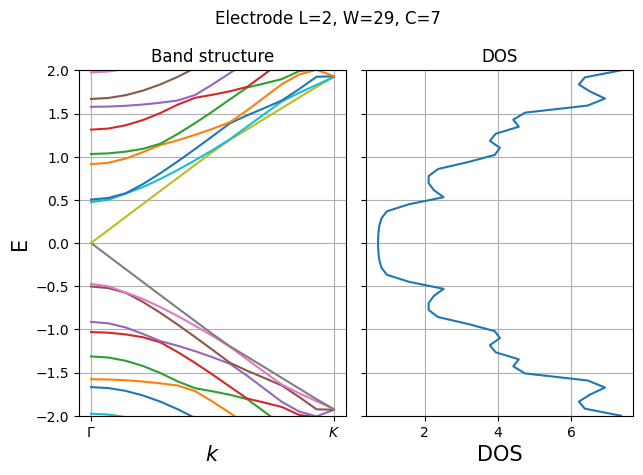

In [7]:
fig, axes = plot_dos_band(electrode, 100, ENERGIES, LWC)
minmax = 2
axes[0].set(ylim=(-minmax, minmax))
folder = path_finder("QTM") / "results" / "L{}_W{}_C{}".format(*LWC)
print(folder)
fig.savefig(folder / f"electrode_bands_DOS.png")

## Self-energy LDOS VS. built-in DOS 

# Convergence for device: Reduced structure (3 arms)

In [8]:
l = 2
i = 6
LWC = infer_centersize(l, i)
electrode, ribbon, device, DATA = load_datastructure(LWC=LWC)
energies, ldos, lr_idx = DATA["energies"], DATA["ldos"], DATA["lr_idx"]

Nk, NE, Na = ldos.shape # number of k-points, energy values, and atoms for device
atoms_style = mark_electrode(lr_idx)

plot_with_center(device, atoms_style=atoms_style)

(l, i) = (2, 6) are incompatbile. Increasing i.
params : (L, W, C) = (2, 29, 7)


## Plotting LDOS VS. DOS*
*DOS is likely not right - calculated assuming 'pristine'

In [9]:
def interactive_params(device, Nk):
    # Determine k-point options
    DEVICE_CENTER_ATOMS = find_nearest_atoms(device.xyz, device.center(), neighbours=6)
    kpts = sisl.MonkhorstPack(hamiltonian(device), [Nk, 1, 1])
    options = [(f"{[str(Fraction(val).limit_denominator(len(kpts)*2)) for val in kvec]})", i) for i, kvec in enumerate(kpts)]
    ks = ipywidgets.Dropdown(options=options, description="k")
    
    # Determine site (only the centermost)
    sites = ipywidgets.Dropdown(options=DEVICE_CENTER_ATOMS, description="Site")
    
    # Option for using normalized data
    norm = ipywidgets.Checkbox(value=False, description="Normalize", indent=True)
    # same = ipywidgets.Checkbox(value=True, description="Plot in same figure", indent=True)
    return ks, sites, norm


In [10]:
from sisl.viz.processors.math import normalize
def plot_ldos(kidx, s, norm=True):
    """Plot LDOS from self-energy calculation."""
    vmin = ldos[kidx, :, sites.options].mean()
    
    X1 = ldos[kidx, :, s]
    
    fig, axes = plt.subplots(1,1)
    if norm: # plot in the save figure
        X1 = normalize(X1, vmin=vmin, vmax = 1)
        axes.set_xlabel("LDOS (normalized)")
    else:
        axes.set_xlabel(f"LDOS")
    
    axes.plot(X1, energies, label="SE (LDOS)")
    axes.set_ylabel("E")
    axes.axvline(0, color="k", linestyle="--")
    
    fig.suptitle("L={:}, W={:}, C={:}".format(*LWC))

ks, sites, norm = interactive_params(device, Nk=Nk)
interact(plot_ldos, kidx=ks, s=sites, norm=norm)

warn:0: SislWarning:

Geometry.close_sc has been passed an 'atoms' argument together with an R value larger than the orbital ranges. If used together with 'sparse-matrix.construct' this can result in wrong couplings.



interactive(children=(Dropdown(description='k', options=(("['0', '0', '0'])", 0),), value=0), Dropdown(descrip…

<function __main__.plot_ldos(kidx, s, norm=True)>

## Plot LDOS pr. energy (interactive)

In [11]:
from sisl.viz.processors.math import normalize
def scale_by_ldos(ldos, Eidx, atoms_style = None):
    scaling = lambda E: 10*E + 0.02
    Nk, NE, Ns = ldos.shape
    C_ATOMS = find_nearest_atoms(device.xyz, device.center(), neighbours=6)
    vmin = ldos[..., C_ATOMS].mean()
    
    
    norm_ldos = normalize(ldos, vmin=vmin, vmax=1)
    style = {"atoms": range(Ns),
             "size": 1.1*scaling(norm_ldos[0, Eidx, :])}
    if atoms_style is None:
        atoms_style = []
    
    atoms_style.append(style)
    return atoms_style
    
style = scale_by_ldos(ldos, 0, atoms_style)

In [12]:
_atoms_style = mark_electrode(lr_idx)

def proj_ldos(Eidx):
    _style = scale_by_ldos(ldos, Eidx, _atoms_style)
    fig = device.plot(axes="xy", atoms_style=_style, backend="matplotlib", show_cell=False)
        
        
    fig.suptitle(f"(L, W, C) = {LWC}, E = {ENERGIES[Eidx]:.3f}")
    # fig.show()
    # return fig

# idxs = ipywidgets.Dropdown(options=range(ENERGIES.shape[0]), description="E")
idxs = ipywidgets.IntSlider(min=0, max=len(ENERGIES)-1, description="E")
interact(proj_ldos, Eidx=idxs); 

interactive(children=(IntSlider(value=0, description='E', max=49), Output()), _dom_classes=('widget-interact',…

# Note to self:
* Adjust SE-calc: $\Sigma = i\mathrm{LDOS}(E=0)c$, in Hamiltonian for the LDOS calculation find $c$
    * Try different cancstants.
    * Goal: reduced edge states when plotting PDOS (using LDOS) around E=0
* Plot LDOS (as currently) together with electrode DOS to verify behavior. Try for different widths
* Plot BG Vs. electrode width to find correlation (hopefully converging). 
    * BG is in this case equal to "flat-region" around E=0 in the LDOS plot
* Make new routine for computing LDOS for only center atoms (don't solve for all sites if used for plotting LDOS in center region).
    * Make identical routine, but only solving for atom index for the center region.


**Update:**  
See [electrode_dos](notebooks/electrode_DOS.ipynb) for attempt at combining built-in DOS in *y* and self-energy in *x*


## Scaling self-energy by $\Sigma \leftarrow Sigma + i\mathrm{LDOS}(E=0)C$

In [13]:
from sisl.physics.self_energy import RecursiveSI
from utils import lr_energies, add_lr_energies
from utils.energies import diagonal_of_inverse


# def make_scaling_matrix(ldos0):
#     """Create the matrix for E=0 
#     used for modulating/scaling the self-energies for a range of energies

#     Parameters
#     ----------
#     ldos0 : np.ndarray
#         A array of LDOS for E=0, shape = (Na,) for Na atoms.
#     """
#     D = np.sqrt(ldos0) # shape (Na)
#     return D[:, None] * D[None, :] # shape (Na, Na)
    
# def mod_LDOS(device: 'sisl.Geometry',
#                electrode: 'sisl.Geometry',
#                lr_indices: tuple[np.ndarray, np.ndarray],
#                *,
#                energies: np.ndarray | list = [0.0],
#                Nk: int = 1,
#                eta: float = 1e-5,
#                form: str = "csc",
#                modulate_SE: bool = False) -> np.ndarray:
#     energies = np.asarray(energies)
    
#     C = 0.05 # scaling for Sigma = i*LDOS(E=0)*C
#     Ne = len(energies) # number of energies
#     k_direction = [1, Nk, 1] # direction to sample k 
#     H_D = hamiltonian(device)
#     Na = len(device) # number of atoms
#     H_D.set_nsc([1,1,1])
#     kpts = sisl.MonkhorstPack(H_D, k_direction).k
    
#     H_0 = hamiltonian(electrode)
#     SE = RecursiveSI(H_0, infinite="+A")
    
#     # Precompute LDOS(E=0) if needed
#     if modulate_SE:
#         print(f"using modulated with {C=}")
#         LDOS_E0 = np.zeros((Nk, Na), dtype=complex)
#         E0 = 0.0 + 1j*eta
        
#         for ik, kvec, in enumerate(tqdm(kpts, desc="LDOS E=0")):
#             Hk = H_D.Hk(k=kvec, format=form, dtype=complex)
#             Sk = H_D.Sk(k=kvec, format=form, dtype=complex)
            
#             SE_pair = lr_energies(electrode=SE, En=E0, kvec=kvec)
#             Hk_lr = add_lr_energies(Hk.copy(), SE_pair, lr_indices)
            
#             invG = Sk*E0 - Hk_lr
#             diagG = diagonal_of_inverse(invG)
#             LDOS_E0[ik, :] = -np.imag(diagG) / np.pi
    
#     # Compute all LDSO (optionally modulated)
#     all_ldos = np.zeros(shape=(Nk, Ne, Na), dtype=float)
#     for ik, kvec in enumerate(kpts):
#         Hk = H_D.Hk(k=kvec, format=form, dtype=complex)
#         Sk = H_D.Sk(k=kvec, format=form, dtype=complex)
        
#         if modulate_SE:
#             scale = make_scaling_matrix(LDOS_E0[ik, :])*C
            
#         for ie, E in enumerate(tqdm(energies, desc=f"Energy for ik={ik}")):
#             En = E + 1j*eta
            
#             SigmaL, SigmaR = lr_energies(electrode=SE, En=En, kvec=kvec)
#             if modulate_SE:
#                 NL, _ = SigmaL.shape
#                 NR, _ = SigmaR.shape
#                 SigmaL = SigmaL + 1j*scale[:NL, :NL]
#                 SigmaR = SigmaR + 1j*scale[-NR:, -NR:]
            
#             Hk_lr = add_lr_energies(Hk.copy(), (SigmaL, SigmaR), lr_indices)
#             invG  = Sk*En - Hk_lr
#             diagG = diagonal_of_inverse(invG)
#             all_ldos[ik, ie, :] = -np.imag(diagG) / np.pi
            
    
#     return all_ldos
        
        
        

In [14]:
mod_ldos = multi_LDOS(device=device, electrode=electrode, lr_indices=lr_idx,
                      energies=energies,
                      Nk=1,
                      eta=1e-5,
                      form="csc",
                      modulate_SE=0.1)

warn:0: SislWarning:

Geometry.close_sc has been passed an 'atoms' argument together with an R value larger than the orbital ranges. If used together with 'sparse-matrix.construct' this can result in wrong couplings.



Using modulated SE with C=0.1


LDOS E=0:   0%|          | 0/1 [00:00<?, ?it/s]

Energy for ik=0:   0%|          | 0/50 [00:00<?, ?it/s]

In [26]:
def interactive_params(device, Nk):
    # Determine k-point options
    DEVICE_CENTER_ATOMS = find_nearest_atoms(device.xyz, device.center(), neighbours=6)
    kpts = sisl.MonkhorstPack(hamiltonian(device), [Nk, 1, 1])
    options = [(f"{[str(Fraction(val).limit_denominator(len(kpts)*2)) for val in kvec]})", i) for i, kvec in enumerate(kpts)]
    ks = ipywidgets.Dropdown(options=options, description="k")
    
    # Determine site (only the centermost)
    sites = ipywidgets.Dropdown(options=DEVICE_CENTER_ATOMS, description="Site")
    
    # Option for using normalized data
    norm = ipywidgets.Checkbox(value=False, description="Normalize", indent=True)
    # same = ipywidgets.Checkbox(value=True, description="Plot in same figure", indent=True)
    return ks, sites, norm


In [27]:
def plot_ldos(ldos1, kidx, s, energies, ldos2=None, norm=True):
    """Plot LDOS from self-energy calculation."""
    
    
    vmin = ldos1[kidx, :, sites.options].mean()
    if not ldos2 is None:
        vmin2 = ldos2[kidx, :, sites.options].mean()
        vmin = np.mean([vmin, vmin2])
    
    
    X1 = ldos1[kidx, :, s]
    
    fig, axes = plt.subplots(1,1)
    if norm: # plot in the save figure
        X1 = normalize(X1, vmin=vmin, vmax = 1)
        axes.set_xlabel("LDOS (normalized)")
    else:
        axes.set_xlabel(f"LDOS")
        
        
    
    axes.plot(X1, energies, label="mod LDOS", linestyle=":", lw=3)
    
    if not ldos2 is None:
        X2 = ldos2[kidx, :, s]
        if norm:
            X2 = normalize(X2, vmin=vmin, vmax=1)
        axes.plot(X2, energies, label="LDOS", linestyle="--", alpha=0.8)
        axes.legend()
            
    axes.set_ylabel("E")
    axes.axvline(0, color="k", linestyle="--")
    
    fig.suptitle("L={:}, W={:}, C={:}".format(*LWC))
    fig.savefig("ldos_and_mod_ldos_scale0.05.png")

In [28]:
ks, sites, norm = interactive_params(device, Nk=Nk)
mod_ldos_fixed = ipywidgets.fixed(mod_ldos)
ldos_fixed = ipywidgets.fixed(ldos)
energies_fixed = ipywidgets.fixed(energies)
interact(plot_ldos, kidx=ks, s=sites, norm=norm, ldos1=mod_ldos_fixed, ldos2=ldos_fixed, energies=energies_fixed)

interactive(children=(Dropdown(description='k', options=(("['0', '0', '0'])", 0),), value=0), Dropdown(descrip…

<function __main__.plot_ldos(ldos1, kidx, s, energies, ldos2=None, norm=True)>

In [ ]:
from IPython import get_ipython
get_ipython().__class__.__name__

AttributeError: 'ZMQInteractiveShell' object has no attribute '__name__'

In [19]:
SCALE_FACTOR = 0.3
SCALE_OFFSET = 0.3

In [20]:
norm_ldos_avg_E = normalize(ldos.mean(axis=(0,1)), 0, 1)*SCALE_FACTOR + SCALE_OFFSET
style = mark_electrode(lr_idx)

style.append({"size": norm_ldos_avg_E})
device.plot(axes="xy", atoms_style=style)

In [21]:
norm_ldos_avg_E = normalize(mod_ldos.mean(axis=(0,1)), 0, 1)*SCALE_FACTOR + SCALE_OFFSET
style = mark_electrode(lr_idx)

style.append({"size": norm_ldos_avg_E})
device.plot(axes="xy", atoms_style=style)

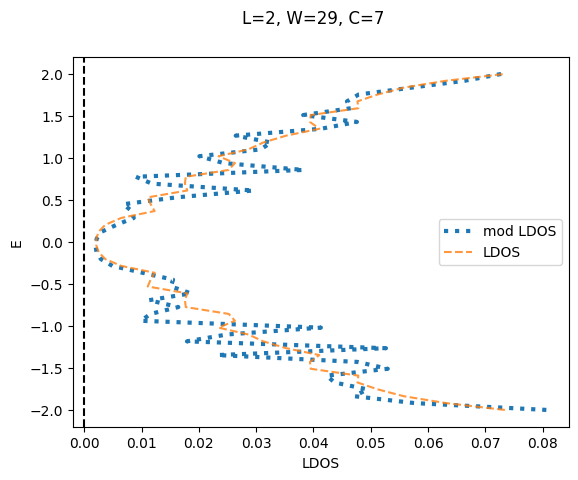

In [22]:
!tree ../results/ -L 1

../results/
├── L1_W13_C6
├── L1_W17_C8
├── L1_W21_C10
├── L1_W25_C12
├── L1_W29_C14
├── L1_W33_C16
├── L1_W5_C2
├── L1_W9_C4
├── L2_W13_C3
├── L2_W17_C4
├── L2_W21_C5
├── L2_W25_C6
├── L2_W29_C7
├── L2_W33_C8
├── L2_W5_C1
├── L2_W9_C2
└── generate_structure.py

16 directories, 1 file


In [23]:
def dos(lwc):
    *_, device, data = load_datastructure(lwc)
    return device, data["ldos"], data["energies"]

In [24]:
device, ldos, energies = dos((1,9,4))
Nk, NE, Na = ldos.shape
ks, sites, norm = interactive_params(device, Nk=Nk)
x = ipywidgets.fixed(ldos)
y = ipywidgets.fixed(energies)
mod_fixed = ipywidgets.fixed(mod_ldos)
interact(plot_ldos, ldos1=x, energies=y, kidx=ks, s=sites, norm=norm, ldos2=mod_fixed)

params : (L, W, C) = (1, 9, 4)


warn:0: SislWarning:

Geometry.close_sc has been passed an 'atoms' argument together with an R value larger than the orbital ranges. If used together with 'sparse-matrix.construct' this can result in wrong couplings.



interactive(children=(Dropdown(description='k', options=(("['0', '0', '0'])", 0),), value=0), Dropdown(descrip…

<function __main__.plot_ldos(ldos1, kidx, s, energies, ldos2=None, norm=True)>

In [25]:
def get_bg(ldos, energies):
    Nk, NE, Ns = ldos.shape
    assert len(energies) == NE, "Arrays size for energies and korresponding LDOS must be equal"
    

In [34]:
infer_centersize(1, 0)

(1, 5, 2)